In [51]:
from langgraph.graph import StateGraph, START , END
from langchain_groq import ChatGroq
from typing import TypedDict, Annotated
from pydantic import BaseModel, Field
from dotenv import load_dotenv
import operator

In [52]:
load_dotenv()

model = ChatGroq(model="llama-3.3-70b-versatile")

In [53]:
class EvaluationSchema(BaseModel):
    feedback: str = Field(description="Detailed Feedback on the essay")
    score: int = Field(description="Score out of 10 for the essay", ge=0, le=10)

In [54]:
structured_model = model.with_structured_output(EvaluationSchema)

In [55]:
essay = """
# Rohit Sharma: The Hitman of Indian Cricket

## Introduction

Rohit Sharma is one of the most accomplished and elegant cricketers in the history of Indian cricket. Known for his effortless stroke play, exceptional timing, and ability to score big centuries, he has earned the nickname **"The Hitman."** Over the years, Rohit has become one of the pillars of the Indian cricket team and has inspired millions of young cricketers around the world.

## Early Life

Rohit Gurunath Sharma was born on **April 30, 1987**, in **Nagpur, Maharashtra, India**. Coming from a humble background, he developed a passion for cricket at a young age. Recognizing his talent, his coaches encouraged him to pursue the sport seriously. He initially started as an off-spinner before eventually becoming a specialist batsman.

## International Career

Rohit Sharma made his international debut for India in **2007**. Although his early years in international cricket were inconsistent, he worked hard to improve his game. His career took a dramatic turn when he was promoted to open the batting in One Day Internationals (ODIs). This decision proved to be one of the best in Indian cricket history.

As an opener, Rohit became one of the world's most destructive batsmen. He is renowned for converting good starts into massive innings and has consistently performed in all three formats of the game.

## Batting Style

Rohit's batting is admired for its elegance and composure. He possesses exceptional timing, making difficult shots appear effortless. His pull shot, cover drive, and lofted straight drive are among the finest in modern cricket.

One of his greatest strengths is his ability to accelerate his scoring after settling in. He often begins cautiously before dominating bowlers with aggressive stroke play.

## Records and Achievements

Rohit Sharma has achieved numerous milestones throughout his career, including:

- The only cricketer to score **three double centuries** in One Day Internationals.
- Holder of the **highest individual ODI score** of **264 runs**.
- Multiple centuries in ICC Cricket World Cup tournaments.
- Captain of the Indian cricket team across multiple formats.
- Led the **Mumbai Indians** franchise to multiple Indian Premier League (IPL) championships.
- Recipient of prestigious national sporting honors for his contributions to Indian cricket.

## Leadership

Rohit Sharma is widely respected as a calm and intelligent leader. His tactical awareness, confidence, and ability to back his players have made him one of the most successful captains in franchise cricket. Under his leadership, Mumbai Indians became one of the most dominant teams in IPL history.

As India's captain, he has focused on building an aggressive yet balanced team culture while mentoring young players and leading by example.

## Impact on Indian Cricket

Rohit Sharma's influence extends beyond statistics. His consistency, resilience, and sportsmanship have made him a role model for aspiring cricketers. His journey from a modest background to becoming one of the greatest opening batsmen demonstrates the importance of dedication, patience, and continuous improvement.

His success has inspired countless young athletes to believe that hard work and perseverance can overcome any obstacle.

## Conclusion

Rohit Sharma is not only one of India's greatest batsmen but also an outstanding leader and ambassador of the game. His remarkable records, elegant batting style, and ability to perform under pressure have secured his place among cricket's all-time greats. As he continues to contribute to Indian cricket, his legacy will inspire future generations of players and fans alike.
"""

In [56]:
prompt = f"""
Evaluate the language quality of the following essay and provide feedback and assign a score out of 10: \n {essay}
"""

result = structured_model.invoke(prompt)

print("Feedback:", result.feedback)
print("Score:", result.score)

Feedback: The essay is well-structured, and the language quality is excellent. The writer uses a range of vocabulary and sentence structures to convey their ideas. The use of headings and subheadings makes the text easy to follow, and the writer provides specific examples and details to support their claims. However, there are a few areas where the writer could improve, such as using more nuanced and complex sentence structures, and providing more depth and analysis in some of the paragraphs. Additionally, there are a few minor errors in punctuation and grammar. Overall, the essay demonstrates a strong command of language and a clear passion for the subject matter.
Score: 9


In [57]:
class EssayState(TypedDict):
    essay: str
    language_feedback: str
    analysis_feedback: str
    clarity_feedback: str
    overall_feedback: str

    individual_scores: Annotated[list[int], operator.add]
    avg_score: float

In [58]:
def evaluate_language(state: EssayState):
    prompt = f"""
    Evaluate the language quality of the following essay and provide feedback and assign a score out of 10: \n {state['essay']}
    """
    result = structured_model.invoke(prompt)
    return {
        'language_feedback': result.feedback,
        'individual_scores': [result.score]
    }

In [59]:
def evaluate_analysis(state: EssayState):
    prompt = f"""
    Evaluate the depth of analysis of the following essay and provide feedback and assign a score out of 10: \n {state['essay']}
    """
    result = structured_model.invoke(prompt)
    return {
        'analysis_feedback': result.feedback,
        'individual_scores': [result.score]
    }

In [60]:
def evaluate_clarity(state: EssayState):
    prompt = f"""
    Evaluate the clarity of thought of the following essay and provide feedback and assign a score out of 10: \n {state['essay']}
    """
    result = structured_model.invoke(prompt)
    return {
        'clarity_feedback': result.feedback,
        'individual_scores': [result.score]
    }

In [61]:
def final_evaluation(state: EssayState):
    prompt = f"""
    Based on the following feedbacks create a summarized feedback \n language feedback - {state['language_feedback']} \n depth of analysis feedback - {state['analysis_feedback']} \n clarity of thought feedback - {state['clarity_feedback']}
    """
    # use normal model 
    overall_feedback = model.invoke(prompt).content

    # average the scores
    avg_score = sum(state['individual_scores']) / len(state['individual_scores']) 
    return {
        'overall_feedback': overall_feedback,
        'avg_score': avg_score
    }

In [62]:
graph = StateGraph(EssayState)

graph.add_node('evaluate_language', evaluate_language)
graph.add_node('evaluate_analysis', evaluate_analysis)
graph.add_node('evaluate_clarity', evaluate_clarity)
graph.add_node('final_evaluation', final_evaluation)


# edges
graph.add_edge(START, 'evaluate_language')
graph.add_edge(START, 'evaluate_analysis')
graph.add_edge(START, 'evaluate_clarity')

graph.add_edge('evaluate_language', 'final_evaluation')
graph.add_edge('evaluate_analysis', 'final_evaluation')
graph.add_edge('evaluate_clarity', 'final_evaluation')

graph.add_edge('final_evaluation', END)

workflow = graph.compile()


In [63]:
# execute
initial_state = {
    'essay': essay
}

final_state = workflow.invoke(initial_state)
print("Final State:", final_state)


Final State: {'essay': '\n# Rohit Sharma: The Hitman of Indian Cricket\n\n## Introduction\n\nRohit Sharma is one of the most accomplished and elegant cricketers in the history of Indian cricket. Known for his effortless stroke play, exceptional timing, and ability to score big centuries, he has earned the nickname **"The Hitman."** Over the years, Rohit has become one of the pillars of the Indian cricket team and has inspired millions of young cricketers around the world.\n\n## Early Life\n\nRohit Gurunath Sharma was born on **April 30, 1987**, in **Nagpur, Maharashtra, India**. Coming from a humble background, he developed a passion for cricket at a young age. Recognizing his talent, his coaches encouraged him to pursue the sport seriously. He initially started as an off-spinner before eventually becoming a specialist batsman.\n\n## International Career\n\nRohit Sharma made his international debut for India in **2007**. Although his early years in international cricket were inconsiste

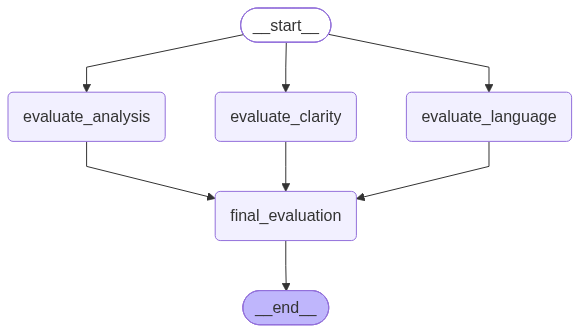

In [64]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())